# Maximum Mean Discrepancy
- a kernel based statistical test used to determine whether given two distribution are the same.
- MMD can be used as a loss/cost function in various machine learning algorithms such as `density estimation`, `generative models` and also in `invertible neural networks` utilized in inverse problems.
- Main advantages are easy implementation and rich kernel based theory behind the idea that lends itself to a formal analysis.
- ref: https://www.kaggle.com/code/onurtunali/maximum-mean-discrepancy#References

# Formal Definition

Maximum mean discrepancy (MMD) can be defined in two different ways which are equivalent to each other:

1. *MMD* is a distance (difference) between *feature means*.
2. *MMD* is an integral probability metric.

Let's start with the concepts used in definition of feature means. Firstly given an $X$, a feature map $\phi$ maps $X$ to an another space $\mathcal{F}$ such that $\phi(X) \in \mathcal{F}$. Assuming $\mathcal{F}$ satisfies the necessary conditions, we can benefit from the kernel trick to compute `the inner product` in $\mathcal{F}$:

$$ X, Y \text{ such that} ~~ k(X, Y) = \langle \phi(X), \phi(Y) \rangle_{\mathcal{F}} $$

**1. Feature means:** Given a probability measure $P$ on $\mathcal{X}$, feature means (or mean embedding as sometimes called in the literature) is an another feature map that takes $\phi(X)$ and maps it to the means of every coordinate of $\phi(X)$:

$$ \mu_{p} ~ (\phi(X)) = \left[ E[\phi(X_{1})], \cdots , E[\phi(X_{m})] \right]^{T} \tag{1} $$ 

Here, $E[\phi(X_i)]$ represents the expected value of the $i$-th feature $\phi(X_i)$ in the feature space, which is the corresponding mean value. This expected value is calculated based on the probability distribution $P$ over the data in the feature space.

Inner product of feature means of $X \sim P$ and $Y \sim Q$ can be written in terms of kernel function such that:

$$ \langle \mu_{P}~(\phi(X)), \mu_{Q}~(\phi(Y)) \rangle_{\mathcal{F}} = E_{P,Q}~ [\langle \phi(X), \phi(Y) \rangle_{\mathcal{F}}] = E_{P,Q}~ [k(X,Y)] \tag{2}$$

**2. Maximum mean discrepancy:** Given $X,Y$ maximum mean discrepancy is the distance between feature means of $X,Y$:

$$ MMD^{2}(P,Q) = \Vert \mu_{P} - \mu_{Q} \Vert^{2} _{\mathcal{F}} \tag{3} $$ 

For convenience we have left out the $\phi(\cdot)$ parts. If we use the norm induced by the inner product such that $\Vert x \Vert = \sqrt{\langle x, x \rangle}$, the equation (3) becomes

$$ MMD^{2}(P,Q) = \langle \mu_{P} - \mu_{Q}, ~ \mu_{P} - \mu_{Q} \rangle = \langle \mu_{P}, \mu_{P} \rangle -2 \langle \mu_{P}, \mu_{Q} \rangle + \langle \mu_{Q}, \mu_{Q} \rangle $$

Using the equation (2), finally above expression becomes

$$ MMD^{2}(P,Q) = E_{P}~ [k(X,X)] - 2 E_{P,Q}~ [k(X,Y)] + E_{Q}~ [k(Y,Y)] \tag{4} $$

We will use the equation (4) in the derivation of empirical estimate of the MMD.

- **Remark:** The term maximum in maximum mean discrepancy comes from the second definition of MMD which is an integral probability metric including a supremum. This definition utilize a supremum and a function belonging to a unit ball $F$ in Reproducing Kernel Hilbert Space. We are only giving the formal definition and remind the reader that both definition are equivalent. For further information please refer to [[1]](#references)

$$ MMD(P, Q; \mathcal{F}) = \underset{\Vert f \Vert \leq 1}{sup~} E_{X} [f(X)] - E_{Y} [f(Y)] $$

**3. Empirical estimation of MMD:** Even though we are working with distributions so far, in real life settings we don't have access to the underlying distribution of our data. For this reason, it is possible to use an estimate for the equation (4) with following formula:


$$ MMD^{2}(X,Y) = \underbrace{\frac{1}{m (m-1)} \sum_{i} \sum_{j \neq i} k(\mathbf{x_{i}}, \mathbf{x_{j}})}_\text{A} - \underbrace{2 \frac{1}{m.m} \sum_{i} \sum_{j} k(\mathbf{x_{i}}, \mathbf{y_{j}})}_\text{B} + \underbrace{\frac{1}{m (m-1)} \sum_{i} \sum_{j \neq i} k(\mathbf{y_{i}}, \mathbf{y_{j}})}_\text{C} \tag{5} $$

One interpretation of the equation (5) is that $\mathbf{x_{i}}$'s are the data points we already have and $\mathbf{y_{i}}$'s are the generated examples so that MMD score guides us towards the evaluation of underlying distributions. In the next section, we will demonstrate how to implement the equation (5) in pytorch and use the MMD as a training criteria in generative models such that our distribution model doesn't diverge from the given data.

![image.png](./img/mmd.png)

In [1]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from scipy.optimize import minimize

def compute_mmd(X, Y, kernel='rbf', gamma=None):
    if kernel == 'rbf':
        # For details, see : def MMD(x, y, kernel)
        K_X = rbf_kernel(X, gamma=gamma)
        K_Y = rbf_kernel(Y, gamma=gamma)
        K_XY = rbf_kernel(X, Y, gamma=gamma)
    else:
        raise ValueError('Unsupported kernel type.')

    mmd = np.mean(K_X) + np.mean(K_Y) - 2 * np.mean(K_XY)
    return mmd

def mmd_embedding_loss(params, Xs, Xt, d, kernel='rbf', gamma=None):
    W = params.reshape((Xs.shape[1], d))
    Zs = Xs.dot(W)
    Zt = Xt.dot(W)
    mmd = compute_mmd(Zs, Zt, kernel=kernel, gamma=gamma)
    return mmd

# data
Xs = np.random.rand(100, 5)
Xt = np.random.rand(80, 5)

# dimension of the embedding
d = 2

# initialize the embedding matrix
W_init = np.random.rand(Xs.shape[1], d)

# minimize the MMD loss
res = minimize(mmd_embedding_loss, W_init.ravel(), args=(Xs, Xt, d), method='L-BFGS-B')
W_opt = res.x.reshape((Xs.shape[1], d))

# compute the embedding representations
Zs = Xs.dot(W_opt)
Zt = Xt.dot(W_opt)

print("the representation of embedding source domain：", Zs)
print("the representation of embedding target domain：", Zt)
print("the shape of embedding source domain：", Zs.shape)
print("the shape of embedding target domain：", Zt.shape)

the representation of embedding source domain： [[0.84222321 0.74291931]
 [0.79149207 0.75803337]
 [1.18161715 1.09827908]
 [1.33275892 1.28663169]
 [1.18745771 1.11615936]
 [0.75399819 0.68310624]
 [0.70271202 0.63593842]
 [0.64547469 0.71411866]
 [1.30543668 1.23751305]
 [0.80087561 0.76207348]
 [1.41952766 1.43381401]
 [0.62274016 0.55937887]
 [1.21313679 1.12756339]
 [1.23871815 1.13814655]
 [1.21104283 1.08988169]
 [0.89447222 0.80537037]
 [0.98222725 0.96115801]
 [1.38097478 1.35161079]
 [1.09303609 0.99981029]
 [1.23192499 1.11664938]
 [0.8550442  0.87033246]
 [0.66327928 0.71335549]
 [0.97210574 0.9331575 ]
 [1.15009834 1.13103964]
 [1.18355646 1.12241952]
 [0.8219037  0.72576192]
 [0.88652026 0.80761962]
 [1.08212759 1.09640651]
 [0.70863742 0.65772108]
 [0.68787838 0.58627316]
 [1.21608072 1.18587887]
 [1.16258299 1.07975474]
 [1.32493585 1.25225266]
 [0.97970048 0.98307981]
 [1.54239371 1.51977732]
 [0.74383693 0.7021031 ]
 [1.56959579 1.49786674]
 [1.29221924 1.20216895]
 [1

# Implementation of MMD

In this section, we code the equation (5) in pytorch. This implementation benefits greatly from the pytorch forum discussion in [here](https://discuss.pytorch.org/t/maximum-mean-discrepancy-mmd-and-radial-basis-function-rbf/1875). In addition to MMD, curious reader can find custom loss function implementations using pytoch in [here](https://discuss.pytorch.org/t/build-your-own-loss-function-in-pytorch/235). Main idea behind the code is first obtaining the similarity matrices between  $X$ and $X$, $X$ and $Y$, finally $Y$ and $Y$ with given distance metric, then plugging the results to kernel specific function such as exponential. 

For example, let's say kernel in question is gaussian meaning 

$$ k(\mathbf{x_{i}}, \mathbf{x_{j}}) = \exp \left(\frac{- \Vert \mathbf{x_{i}} - \mathbf{x_{j}} \Vert^{2}}{2\sigma^{2}}\right) = \exp \left(\frac{-1}{\sigma^{2}} [\mathbf{x_{i}}^\intercal \mathbf{x_{i}} - 2 \mathbf{x_{i}}^\intercal \mathbf{x_{j}} + \mathbf{x_{j}}^\intercal \mathbf{x_{j}}]\right) $$

If we can construct a matrix with elements such that for every i and j corresponding element is $[\mathbf{x_{i}}^\intercal \mathbf{x_{i}} - 2 \mathbf{x_{i}}^\intercal \mathbf{x_{j}} + \mathbf{x_{j}}^\intercal \mathbf{x_{j}}]$, then it is possible to just plug that matrix into `pytorch.exp()` for the result.

![image.png](./img/multiscale.png)

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def MMD(x, y, kernel):
    """Emprical maximum mean discrepancy. The lower the result
       the more evidence that distributions are the same.

    Args:
        x: first sample, distribution P
        y: second sample, distribution Q
        kernel: kernel type such as "multiscale" or "rbf"
    """
    xx, yy, zz = torch.mm(x, x.t()), torch.mm(y, y.t()), torch.mm(x, y.t())
    rx = (xx.diag().unsqueeze(0).expand_as(xx))
    ry = (yy.diag().unsqueeze(0).expand_as(yy))
    
    dxx = rx.t() + rx - 2. * xx 
    dyy = ry.t() + ry - 2. * yy 
    dxy = rx.t() + ry - 2. * zz 
    
    XX, YY, XY = (torch.zeros(xx.shape).to(device),
                  torch.zeros(xx.shape).to(device),
                  torch.zeros(xx.shape).to(device))
    
    # a^2*(a^2+|x-y|^2)^-1, where a = multiscale
    if kernel == "multiscale":
        
        bandwidth_range = [0.2, 0.5, 0.9, 1.3]
        for a in bandwidth_range:
            XX += a**2 * (a**2 + dxx)**-1
            YY += a**2 * (a**2 + dyy)**-1
            XY += a**2 * (a**2 + dxy)**-1
            
    if kernel == "rbf":
      
        bandwidth_range = [10, 15, 20, 50]
        for a in bandwidth_range:
            XX += torch.exp(-0.5*dxx/a)
            YY += torch.exp(-0.5*dyy/a)
            XY += torch.exp(-0.5*dxy/a)

    return torch.mean(XX + YY - 2. * XY)

<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
C:\Users\a4022\AppData\Local\Temp\ipykernel_32728\503158625.py:47: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title("Distribution of $X \sim P(X)$")
C:\Users\a4022\AppData\Local\Temp\ipykernel_32728\503158625.py:55: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title("Distribution of $Y \sim Q(Y)$")


MMD result of X and Y is 0.9491567015647888


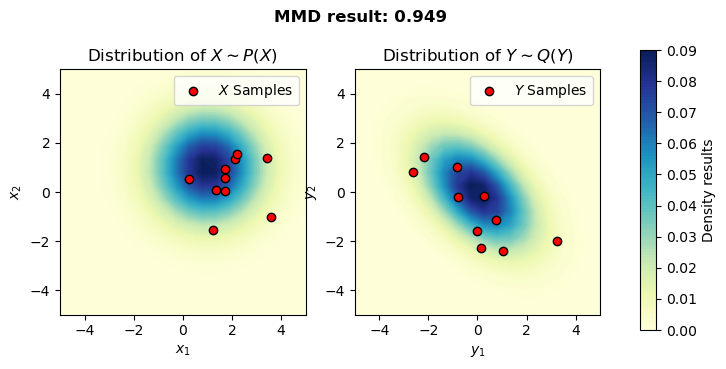

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.stats import dirichlet 
from torch.distributions.multivariate_normal import MultivariateNormal 


m = 20 # sample size
x_mean = torch.zeros(2)+1
y_mean = torch.zeros(2)
x_cov = 2*torch.eye(2) # IMPORTANT: Covariance matrices must be positive definite
y_cov = 3*torch.eye(2) - 1

px = MultivariateNormal(x_mean, x_cov)
qy = MultivariateNormal(y_mean, y_cov)
x = px.sample([m]).to(device)
y = qy.sample([m]).to(device)

result = MMD(x, y, kernel="multiscale")

print(f"MMD result of X and Y is {result.item()}")

# ---- Plotting setup ----

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4), dpi=100)
#plt.tight_layout() 
delta = 0.025

x1_val = np.linspace(-5, 5, num=m)
x2_val = np.linspace(-5, 5, num=m)

x1, x2 = np.meshgrid(x1_val, x2_val)

px_grid = torch.zeros(m,m)
qy_grid = torch.zeros(m,m)


for i in range(m):
    for j in range(m):
        px_grid[i,j] = multivariate_normal.pdf([x1_val[i],x2_val[j]], x_mean, x_cov)
        qy_grid[i,j] = multivariate_normal.pdf([x1_val[i],x2_val[j]], y_mean, y_cov)


CS1 = ax1.contourf(x1, x2, px_grid,100, cmap=plt.cm.YlGnBu)
ax1.set_title("Distribution of $X \sim P(X)$")
ax1.set_ylabel('$x_2$')
ax1.set_xlabel('$x_1$')
ax1.set_aspect('equal')
ax1.scatter(x[:10,0].cpu(), x[:10,1].cpu(), label="$X$ Samples", marker="o", facecolor="r", edgecolor="k")
ax1.legend()

CS2 = ax2.contourf(x1, x2, qy_grid,100, cmap=plt.cm.YlGnBu)
ax2.set_title("Distribution of $Y \sim Q(Y)$")
ax2.set_xlabel('$y_1$')
ax2.set_ylabel('$y_2$')
ax2.set_aspect('equal')
ax2.scatter(y[:10,0].cpu(), y[:10,1].cpu(), label="$Y$ Samples", marker="o", facecolor="r", edgecolor="k")
ax2.legend()
#ax1.axis([-2.5, 2.5, -2.5, 2.5])

# Add colorbar and title
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(CS2, cax=cbar_ax)
cbar.ax.set_ylabel('Density results')
plt.suptitle(f"MMD result: {round(result.item(),3)}",y=0.95, fontweight="bold")
plt.show()

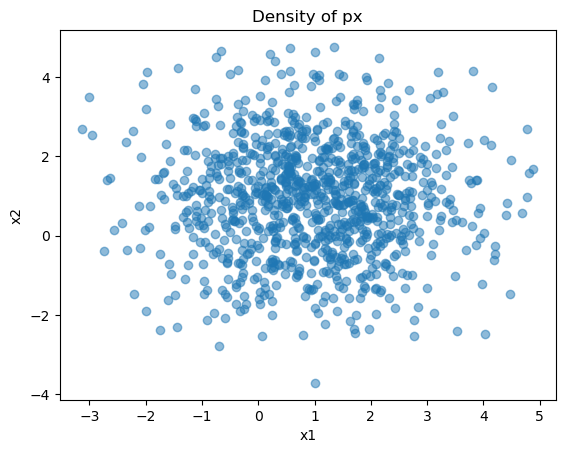

In [8]:
import matplotlib.pyplot as plt

# Generate samples
samples = px.sample([1000]).numpy()

# Plot density
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title('Density of px')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()